In [20]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Loading and Preprocessing our Dataset

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

In [22]:



df = pd.read_csv('translated_4000_reviews.csv')

print(df.head())


                                       Nepali Review  rating label
0  मैले यो किन्नुको कारण यही उत्पादन हो। दुई ठूला...     5.0    CG
1  सजिलो सेटअप भएकोमा धेरै राम्रो लाग्यो। मैले पन...     5.0    CG
2  मैले यो किट भेटें र यो तुरुन्तै लोकप्रिय भयो। ...     5.0    CG
3  राम्रा पात्रहरू र कथावस्तु.. साहसिक कार्य भन्द...     3.0    OR
4  यो एक उच्च गुणस्तर सामाग्री छ। मात्र समस्या यो...     5.0    CG


In [23]:
print(df['rating'].value_counts())

rating
5.0    2424
4.0     806
3.0     374
1.0     251
2.0     215
Name: count, dtype: int64


In [24]:

# Check for missing values
df = df.dropna()
df['label'] = df['label'].apply(lambda x: 1 if x == 'OR' else 0)
df.head()

# Convert ratings to string and concatenate with review text
df["combined_text"] = df["rating"].astype(str) + " [SEP] " + df["Nepali Review"]


# Splitting dataset into train & test sets
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["combined_text"].tolist(), df["label"].tolist(), test_size=0.2, random_state=1)

# Load NepBERT tokenizer
model_name = "NepBERTa/NepBERTa"  
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenize the text
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)


In [25]:
df.head()

,Nepali Review,rating,label,combined_text
0,मैले यो किन्नुको कारण यही उत्पादन हो। दुई ठूला...,5.0,0,5.0 [SEP] मैले यो किन्नुको कारण यही उत्पादन हो...
1,सजिलो सेटअप भएकोमा धेरै राम्रो लाग्यो। मैले पन...,5.0,0,5.0 [SEP] सजिलो सेटअप भएकोमा धेरै राम्रो लाग्य...
2,मैले यो किट भेटें र यो तुरुन्तै लोकप्रिय भयो। ...,5.0,0,5.0 [SEP] मैले यो किट भेटें र यो तुरुन्तै लोकप...
3,राम्रा पात्रहरू र कथावस्तु.. साहसिक कार्य भन्द...,3.0,1,3.0 [SEP] राम्रा पात्रहरू र कथावस्तु.. साहसिक ...
4,यो एक उच्च गुणस्तर सामाग्री छ। मात्र समस्या यो...,5.0,0,5.0 [SEP] यो एक उच्च गुणस्तर सामाग्री छ। मात्र...


Convert Data to PyTorch Dataset

In [26]:
import torch

class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

# Convert to PyTorch dataset
train_dataset = ReviewDataset(train_encodings, train_labels)
test_dataset = ReviewDataset(test_encodings, test_labels)


Loading Pre-trained NepBERT Model

In [27]:
from transformers import AutoModelForSequenceClassification

# Load NepBERT with 2 output labels (Fake vs. Real)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2, from_tf=True)


All TF 2.0 model weights were used when initializing BertForSequenceClassification.

All the weights of BertForSequenceClassification were initialized from the TF 2.0 model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use BertForSequenceClassification for predictions without further training.


Model Training

In [28]:
import os
from transformers import Trainer, TrainingArguments

# Disable W&B if not using it
os.environ["WANDB_DISABLED"] = "true"

# Define training parameters
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",  # Updated from evaluation_strategy
    save_strategy="epoch",
    per_device_train_batch_size=10,
    per_device_eval_batch_size=10,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir="./logs",
    fp16=True,
    # gradient_accumulation_steps=4,  # Accumulates gradients over 4 steps
)


# Use Trainer API to fine-tune NepBERT
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

# Train the model
trainer.train()


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss
1,No log,0.581207
2,0.456800,0.332622
3,0.456800,0.444907
4,0.217000,0.393313
5,0.070000,0.465250


TrainOutput(global_step=1630, training_loss=0.23158459429360606, metrics={'train_runtime': 261.3452, 'train_samples_per_second': 62.293, 'train_steps_per_second': 6.237, 'total_flos': 1070861995315200.0, 'train_loss': 0.23158459429360606, 'epoch': 5.0})

Model Evaluation

NepBERTa Model Accuracy: 0.91
Classification Report for NepBERTa:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       428
           1       0.94      0.87      0.90       386

    accuracy                           0.91       814
   macro avg       0.91      0.91      0.91       814
weighted avg       0.91      0.91      0.91       814



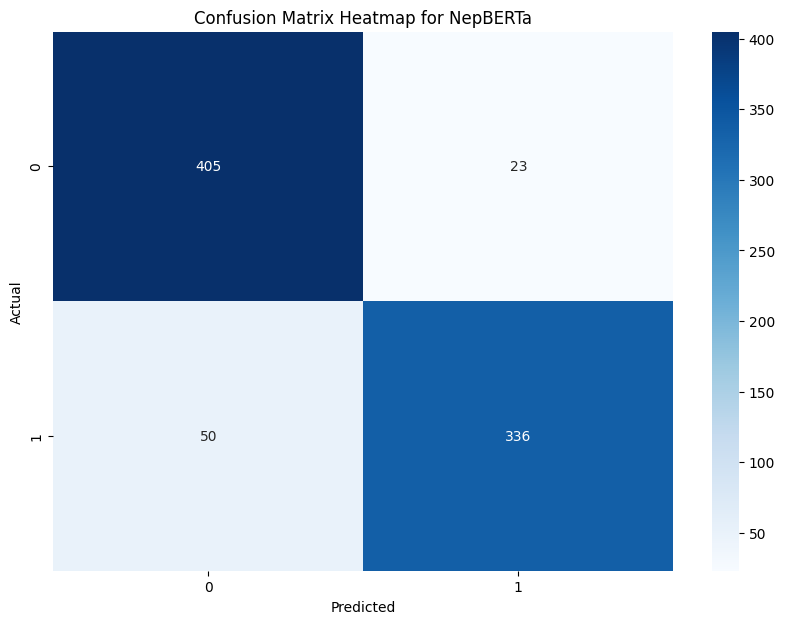

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Get predictions
preds = trainer.predict(test_dataset)
pred_labels = torch.argmax(torch.tensor(preds.predictions), axis=1).numpy()

# Compute accuracy
accuracy = accuracy_score(test_labels, pred_labels)
print(f"NepBERTa Model Accuracy: {accuracy:.2f}")
print("Classification Report for NepBERTa:")
print(classification_report(test_labels, pred_labels))

import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(test_labels, pred_labels)

# Get the unique class labels
class_names = sorted(list(set(test_labels)))

# Create a heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap for NepBERTa')
plt.show()

**Save and Test the Model**

Using "save_pretrained" which is the preferred Hugging Face's method

In [30]:
# Save model using Hugging Face's method
model.save_pretrained("./fine_tuned_nepbert")

# Load model using Hugging Face's method
# from transformers import BertForSequenceClassification, BertTokenizer
# model = BertForSequenceClassification.from_pretrained("./fine_tuned_nepbert")
# tokenizer = BertTokenizer.from_pretrained("./fine_tuned_nepbert")


Using pickle

In [31]:
import pickle

# Save the model to a pickle file
with open("nepbert_model.pkl", "wb") as f:
    pickle.dump(model, f)


Checking Model output

In [32]:
from transformers import pipeline

classifier = pipeline("text-classification", model="./fine_tuned_nepbert", tokenizer=tokenizer)
# or
# Load model using Hugging Face's method
# from transformers import BertForSequenceClassification, BertTokenizer
# model = BertForSequenceClassification.from_pretrained("./fine_tuned_nepbert")
# tokenizer = BertTokenizer.from_pretrained("./fine_tuned_nepbert")


Device set to use cuda:0


In [33]:
# Example rating and review
rating = 1
review = "यो होटल ठगि हो।"  # Example Nepali review

# Concatenate rating with review (same format as training)
input_text = f"{rating} [SEP] {review}"

# Get prediction
result = classifier(input_text)

# print(result) #gives following o/p
# [{'label': 'LABEL_0', 'score': 0.9900834560394287}]

# Extract label and confidence score
label = result[0]['label']
score = result[0]['score'] * 100  # Convert to percentage

# Interpret the label (assuming LABEL_0 = Fake, LABEL_1 = Real)
label_text = "Fake" if label == "LABEL_0" else "Real"

# Display output
print(f"Review is {label_text} with {score:.2f}% accuracy.")


Review is Fake with 98.98% accuracy.


In [34]:
# Example rating and review
rating = 5
review = "यसले मेरो फोनलाई चार्जर पूर्ण रूपमा चार्ज भएपछि मात्र चार्ज गर्न अनुमति दिन्छ। यसको एक मात्र नकारात्मक पक्ष भनेको जब तपाईं"

# Concatenate rating with review (same format as training)
input_text = f"{rating} [SEP] {review}"

# Get prediction
result = classifier(input_text)

# Extract label and confidence score
label = result[0]['label']
score = result[0]['score'] * 100  # Convert to percentage

# Interpret the label (assuming LABEL_0 = Fake, LABEL_1 = Real)
label_text = "Fake" if label == "LABEL_0" else "Real"

# Display output
print(f"Review is {label_text} with {score:.2f}% accuracy.")


Review is Fake with 99.85% accuracy.


In [35]:
count= df['rating'].value_counts(normalize= False)

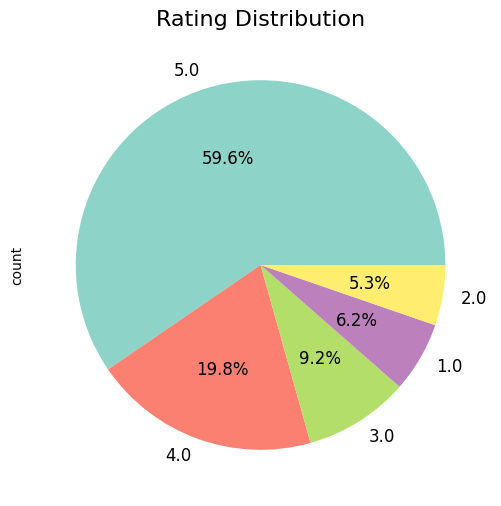

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

count.plot.pie(autopct ='%1.1f%%' , startangle= 0 , cmap= 'Set3', fontsize =12)

plt.title("Rating Distribution" , fontsize = 16)

plt.show()

In [37]:
count_label= df['label'].value_counts(normalize= False)

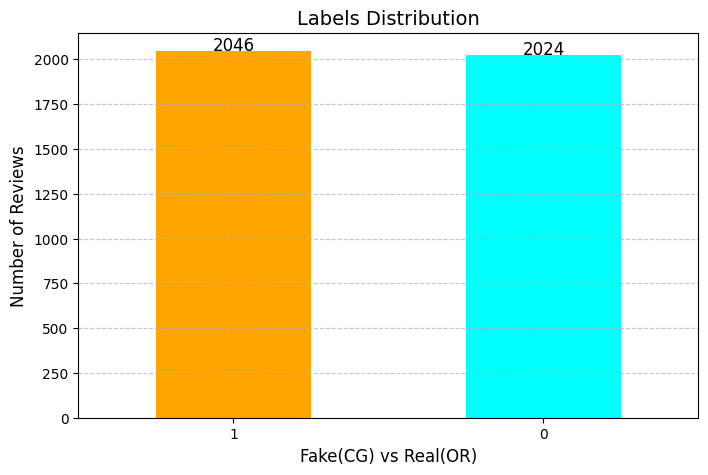

In [38]:
import matplotlib.pyplot as plt


count_label = pd.Series(count_label)

# Plot bar chart
plt.figure(figsize=(8, 5))
ax = count_label.plot(kind='bar', color=['orange', 'cyan'])

# Add title and labels
plt.title("Labels Distribution", fontsize=14)
plt.xlabel("Fake(CG) vs Real(OR)", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)

# Add numeric values on bars
for i, v in enumerate(count_label):
    ax.text(i, v + 3, str(v), ha='center', fontsize=12)

# Show the bar chart
plt.xticks(rotation=0)  # Keep category labels horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add grid for better readability
plt.show()
